# ЛР2: Эксперимент 2.2 — CG vs GD

Сравнение числа итераций метода сопряжённых градиентов и градиентного спуска
для квадратичной задачи при разных размерностях и числах обусловленности.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from oracles import QuadraticOracle
from optimization import linear_conjugate_gradients

rng = np.random.default_rng(42)

In [2]:
def make_spd(n, cond, rng):
    Q, _ = np.linalg.qr(rng.normal(size=(n, n)))
    eigs = np.geomspace(1.0, cond, num=n)
    A = Q @ np.diag(eigs) @ Q.T
    return A

def gradient_descent_quadratic(oracle, x0, tol=1e-4, max_iter=10000):
    x = x0.copy()
    g0 = oracle.grad(x)
    g0_norm_sq = np.dot(g0, g0)
    if g0_norm_sq == 0:
        return x, 0
    for k in range(max_iter):
        g = oracle.grad(x)
        if np.dot(g, g) <= tol * g0_norm_sq:
            return x, k
        Ag = oracle.A.dot(g)
        alpha = np.dot(g, g) / np.dot(g, Ag)
        x = x - alpha * g
    return x, max_iter

In [3]:
dims = [50, 100, 200]
conds = [1e1, 1e2, 1e3, 1e4]
tol = 1e-8

results_cg = np.zeros((len(dims), len(conds)))
results_gd = np.zeros((len(dims), len(conds)))

for i, n in enumerate(dims):
    for j, c in enumerate(conds):
        A = make_spd(n, c, rng)
        b = rng.normal(size=n)
        oracle = QuadraticOracle(A, b)
        x0 = np.zeros(n)

        _, _, hist_cg = linear_conjugate_gradients(
            matvec=lambda v: A.dot(v), b=b, x_0=x0, tolerance=tol,
            max_iter=None, trace=True
        )
        _, it_gd = gradient_descent_quadratic(oracle, x0, tol=tol, max_iter=20000)

        results_cg[i, j] = len(hist_cg['residual_norm']) - 1
        results_gd[i, j] = it_gd

results_cg, results_gd

(array([[ 27.,  50.,  50.,  50.],
        [ 28.,  75., 100., 100.],
        [ 29.,  86., 200., 200.]]),
 array([[   38.,   401.,  3708., 20000.],
        [   38.,   400.,  3668., 20000.],
        [   38.,   338.,  3350., 20000.]]))

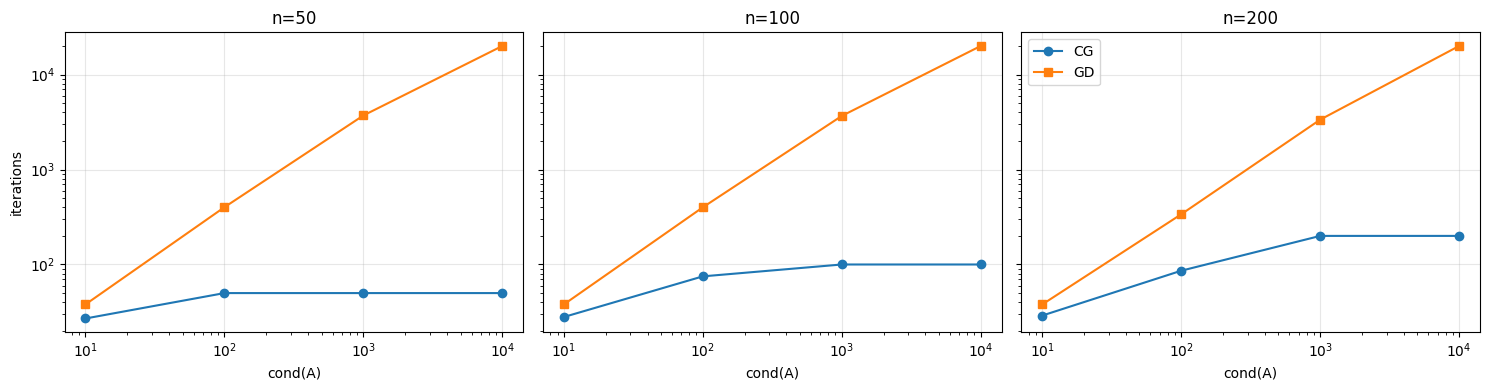

In [4]:
from pathlib import Path

fig, axes = plt.subplots(1, len(dims), figsize=(15, 4), sharey=True)
for i, n in enumerate(dims):
    ax = axes[i]
    ax.plot(conds, results_cg[i], marker='o', label='CG')
    ax.plot(conds, results_gd[i], marker='s', label='GD')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(f'n={n}')
    ax.set_xlabel('cond(A)')
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel('iterations')
axes[-1].legend()
plt.tight_layout()
Path('fig').mkdir(parents=True, exist_ok=True)
plt.savefig('fig/exp2_2_cg_vs_gd.png', dpi=200, bbox_inches='tight')

## Краткие выводы
- CG заметно менее чувствителен к росту обусловленности, чем GD.
- При увеличении размерности преимущество CG обычно сохраняется/усиливается.
- Для квадратичных задач CG в идеале сходится за не более чем `n` шагов (в точной арифметике).